# DE analysis using limma: Normalization, Batch correction and DE analysis
### Kidney example dataset
**Author:** Diana Vera Cruz


## Goal

Perform normalization and DE analysis using the limma package. We recommend to use the `limma-voom` method for DE analysis, as it is the most robust method for this type of data, coupled with the `duplicateCorrelation` function to account for the batch effect. 

## DE question 

**For a given cell type, do we see differences between the normal and DKD segments?**


## Input Data

We will use the tables generated in the previous QC step, they are found in the results folder.

-   **Counts**: Dataframe, or table, including a column with the gene name (Default, `TargetName`).

-   **Sample Annotation**: Sample annotation, it should include a segment name column, (Default, `SegmentDisplayName`) and Coordinate columns (Default, `ROICoordinateX` and `ROICoordinateY`).

In [37]:
out_dir = './GeoMx' ## Or full path for the desired output directory.

In [38]:
## cd /gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2
##sbatch --mem=10G  ./launch_jupyter_conda.sh /gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/conda_envs/geomx_env

## Libraries
library(tidyverse)
library(limma)
library(edgeR)
library(ggalluvial)
library(ggrepel)
library(PCAtools)

In [39]:
## Outdir -> set the results folder. 
out_dir = file.path(out_dir, 'results')
if(!dir.exists( out_dir )) dir.create( out_dir, recursive = T)
## Load data: Counts and metadata.
dt_dir = '/gpfs/data/biocore-workshop/spatial_transcriptomics_bruker_2026_workshop2/GeoMx/results'
counts = read_tsv(file.path(dt_dir, 'tidy_counts.tsv')) %>% column_to_rownames('TargetName') %>% as.matrix()

## Metadata: Format and ensure that the variables of interest are factors, and in the desired order.
metadata = read_tsv(file.path(dt_dir, 'tidy_metadata.tsv')) %>% as.data.frame()
rownames(metadata) = metadata$segment_name
metadata <- mutate(metadata, 
       CellType = case_when(segment == 'Geometric Segment' ~ 'glomeruli', segment == 'PanCK-' ~ 'DistalTubules', TRUE ~ 'ProximalTubules') %>% factor(levels = c('glomeruli', 'ProximalTubules', 'DistalTubules')), 
       class = factor(class, levels = c('normal', 'DKD'))
       )

str(metadata)

Rows: 10028 Columns: 202
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr   (1): TargetName
dbl (201): DSP-1001250007851-H-A02.dcc, DSP-1001250007851-H-A03.dcc, DSP-100...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 201 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (7): segment_name, slide_name, region, segment, class, aoi, pathology
dbl (5): roi, area, nuclei, ROI_Coordinate_X, ROI_Coordinate_Y

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


'data.frame':	201 obs. of  13 variables:
 $ segment_name    : chr  "DSP-1001250007851-H-A02.dcc" "DSP-1001250007851-H-A03.dcc" "DSP-1001250007851-H-A04.dcc" "DSP-1001250007851-H-A05.dcc" ...
 $ slide_name      : chr  "disease3" "disease3" "disease3" "disease3" ...
 $ region          : chr  "glomerulus" "glomerulus" "glomerulus" "glomerulus" ...
 $ segment         : chr  "Geometric Segment" "Geometric Segment" "Geometric Segment" "Geometric Segment" ...
 $ class           : Factor w/ 2 levels "normal","DKD": 2 2 2 2 2 2 2 2 2 2 ...
 $ aoi             : chr  "Geometric Segment-aoi-001" "Geometric Segment-aoi-001" "Geometric Segment-aoi-001" "Geometric Segment-aoi-001" ...
 $ roi             : num  7 8 9 10 11 12 13 14 15 16 ...
 $ area            : num  31798 16920 14312 20033 27583 ...
 $ nuclei          : num  225 132 114 89 132 169 105 55 164 92 ...
 $ pathology       : chr  "abnormal" "abnormal" "abnormal" "abnormal" ...
 $ ROI_Coordinate_X: num  89.1 237.7 174 184.3 374.3 ...
 $ ROI

## Dataset exploration

In [40]:
dplyr::count(metadata, slide_name, CellType, segment, region, class)

slide_name,CellType,segment,region,class,n
<chr>,<fct>,<chr>,<chr>,<fct>,<int>
disease1B,glomeruli,Geometric Segment,glomerulus,DKD,8
disease1B,ProximalTubules,PanCK+,tubule,DKD,3
disease1B,DistalTubules,PanCK-,tubule,DKD,5
disease2B,glomeruli,Geometric Segment,glomerulus,DKD,9
disease2B,ProximalTubules,PanCK+,tubule,DKD,2
disease2B,DistalTubules,PanCK-,tubule,DKD,6
disease3,glomeruli,Geometric Segment,glomerulus,DKD,46
disease3,ProximalTubules,PanCK+,tubule,DKD,4
disease3,DistalTubules,PanCK-,tubule,DKD,6


## Normalization

We will start with the raw counts and Compute Q3 normalization.

In [41]:
## DGEList: Create object from counts, metadata and main variable of interest.
dge <- DGEList(counts = counts, samples = metadata)

## Q3 normalization
dge <- calcNormFactors(dge, method = 'upperquartile')

To obtain $log_2CPM$ values, we will use voom, in this case we use a simple design matrix, that captures our main variables of interest and the batch variable.

In [42]:
## Initial design matrix: Include key variables that explain the variation in the study. 
design = model.matrix(~CellType + class + slide_name, data = metadata)
logcpm <- voom(dge, design)$E

Coefficients not estimable: slide_namenormal4 


Warning message:
“Partial NA coefficients for 10028 probe(s)”


### PCA

We will perform a PCA analysis to explore the variation in the dataset, using logCPM values.

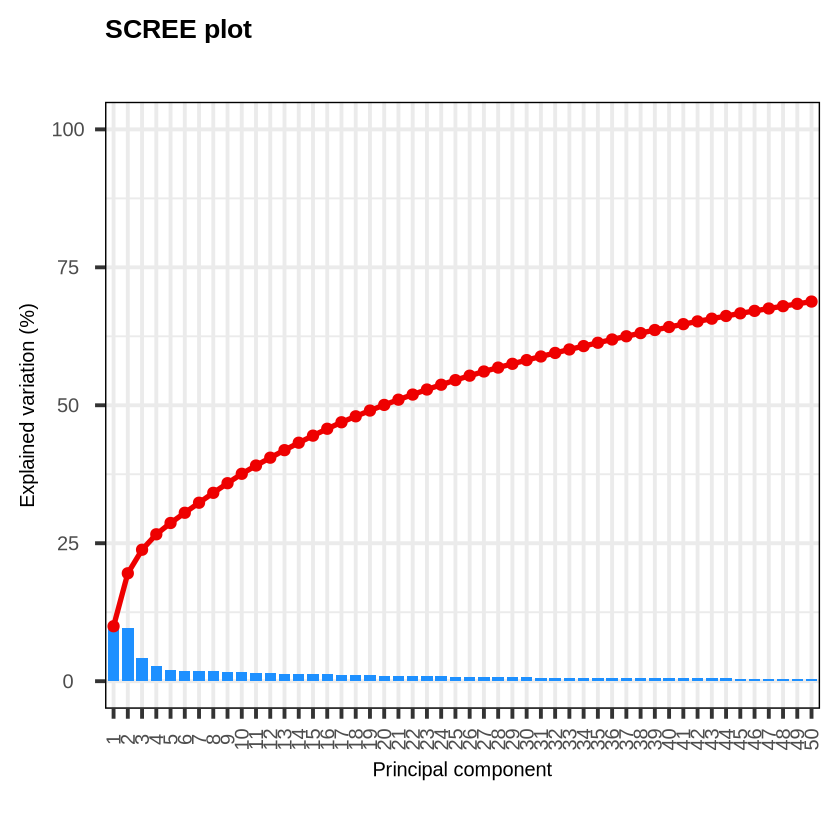

In [43]:
pca <- pca(logcpm, meta = metadata, scale = T)

screeplot(pca, components = 1:50, axisLabSize = 12)

Ignoring unknown labels:
• fill : ""


Ignoring unknown labels:
• fill : ""


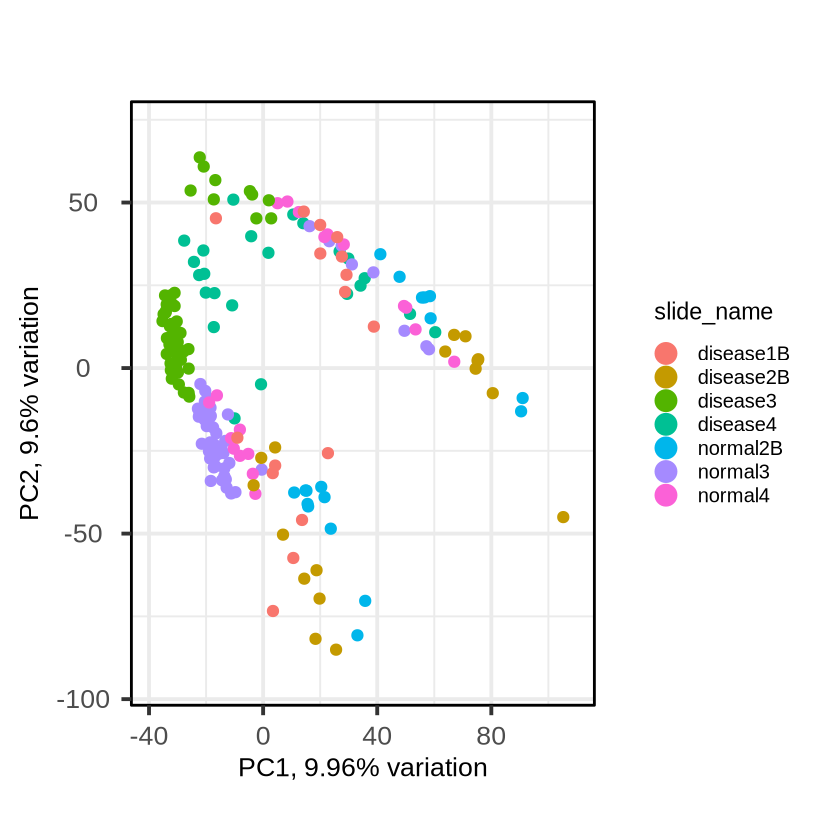

Ignoring unknown labels:
• fill : ""


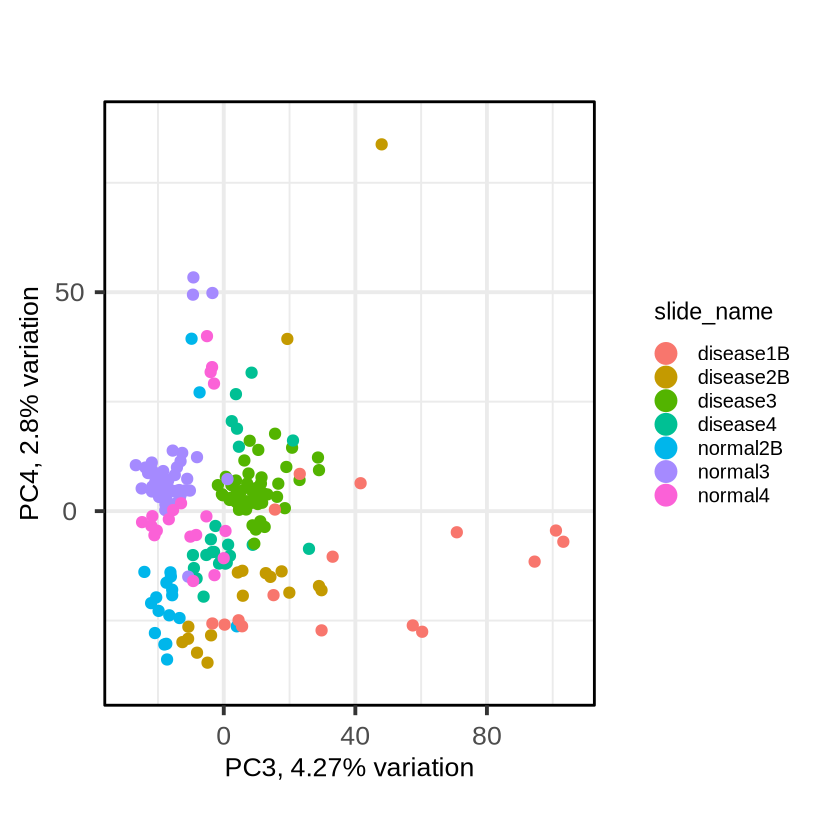

Ignoring unknown labels:
• fill : ""


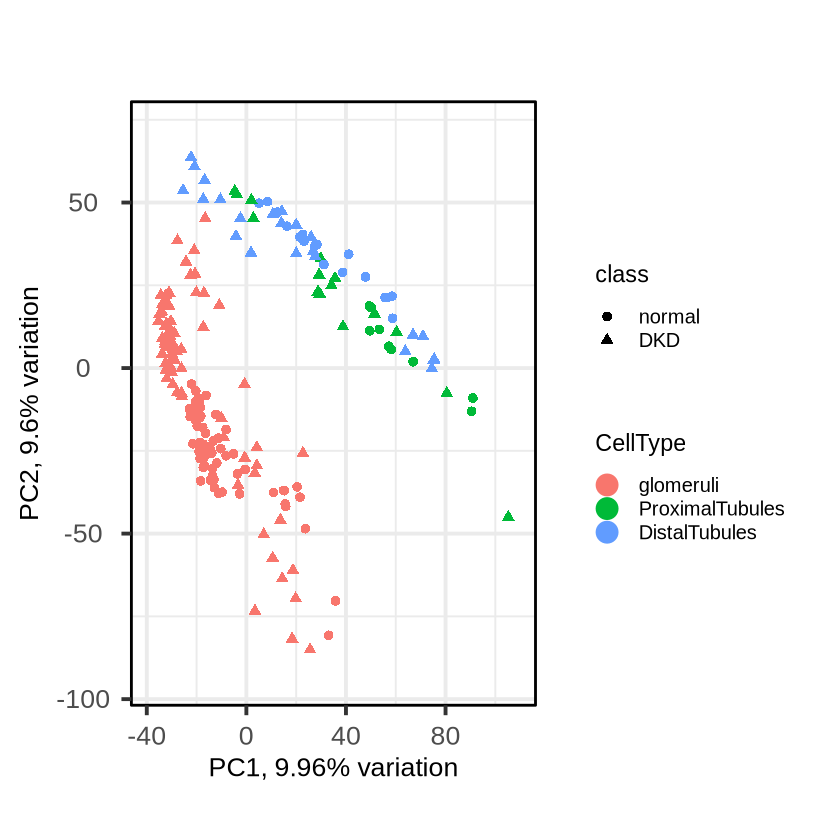

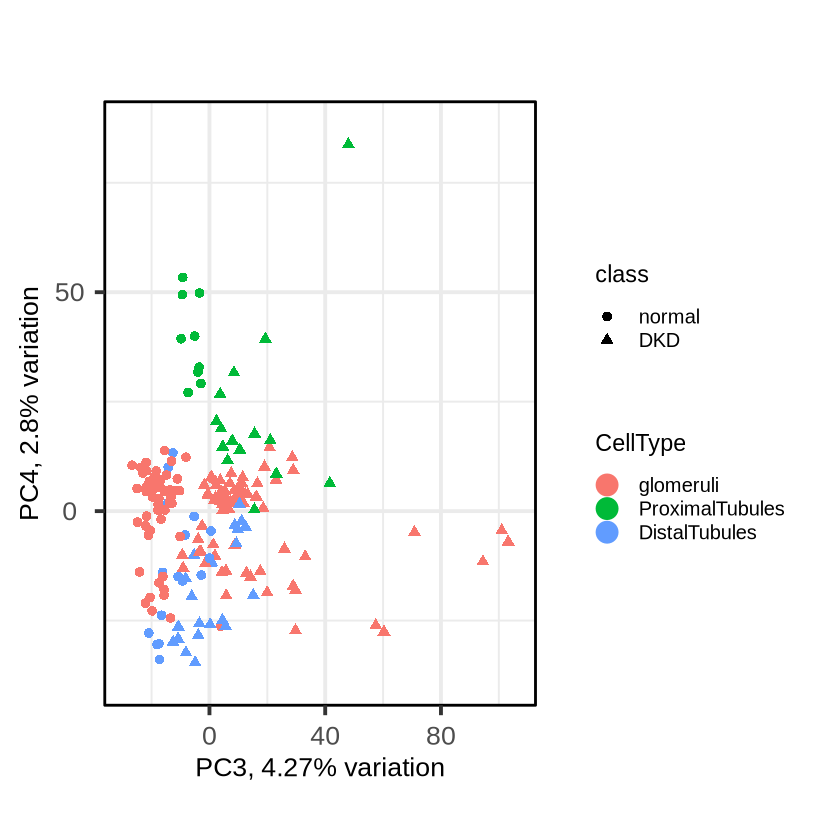

In [44]:
biplot(pca, pointSize = 2, colby = "slide_name", lab = NULL, legendPosition = 'right')
biplot(pca, x = 'PC3', y = 'PC4', pointSize = 2, colby = "slide_name", lab = NULL, legendPosition = 'right')

biplot(pca, pointSize = 2, colby = "CellType", shape = "class", lab = NULL, legendPosition = 'right')
biplot(pca, x = 'PC3', y = 'PC4', pointSize = 2, colby = "CellType", shape = "class", lab = NULL, legendPosition = 'right')

## DE analysis: `limma-voom`

DE analysis performed using the `limma` package. edgeR, limma-voom and DESeq2 are recommended for GeoMx data.

Strong preference for `limma-voom` using duplicate correlation, as it is the most robust method for this type of data. Does not modify the variation in the dataset and assumes a mixed effect for the batch variable.

DESeq2 is recommended when you have raw counts, and you want to include batch variables as covariates but you also have a full-rank matrix (Slide is not confounded with the variable of interest).

In this case, we will start from the original dataset, since we will use the duplicated correlation to account for the batch effect.

**Design Model**: \~ CellType + Class:CellType

In [45]:
## Block variable set to the batch variable
block_var = metadata$slide_name

## Design model. 
design = model.matrix(~0 + CellType + class:CellType, data = metadata)
## Update contrasts names. 
colnames(design) <- gsub("CellType|class", "", colnames(design)) %>% gsub(pattern = ':', rep = '_')

#### Biological Coefficient of Variation

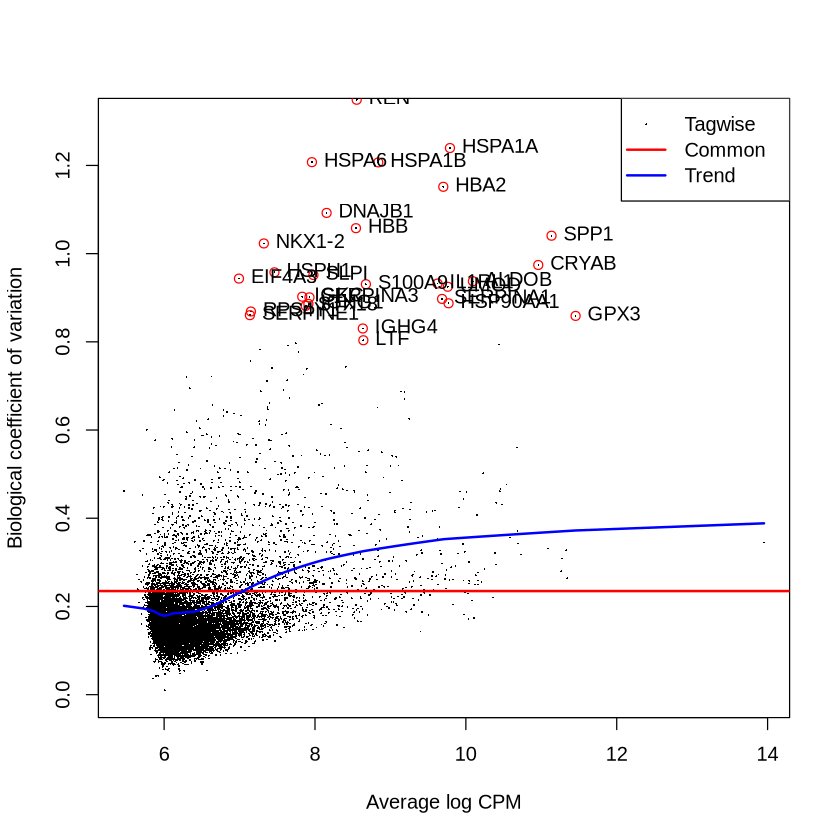

In [46]:
keep <- filterByExpr(dge, design)
dge_all <- dge[keep, ]
dge_all <- estimateDisp(dge_all, design = design, robust = TRUE)

plotBCV(dge_all, ylim = c(0, 1.3))
bcv_df <- data.frame(
  'BCV' = sqrt(dge_all$tagwise.dispersion),
  'AveLogCPM' = dge_all$AveLogCPM,
  'gene_id' = rownames(dge_all)
)

highbcv <- bcv_df$BCV > 0.8
highbcv_df <- bcv_df[highbcv, ]
points(highbcv_df$AveLogCPM, highbcv_df$BCV, col = "red")
text(highbcv_df$AveLogCPM, highbcv_df$BCV, labels = highbcv_df$gene_id, pos = 4)

#### Fit model

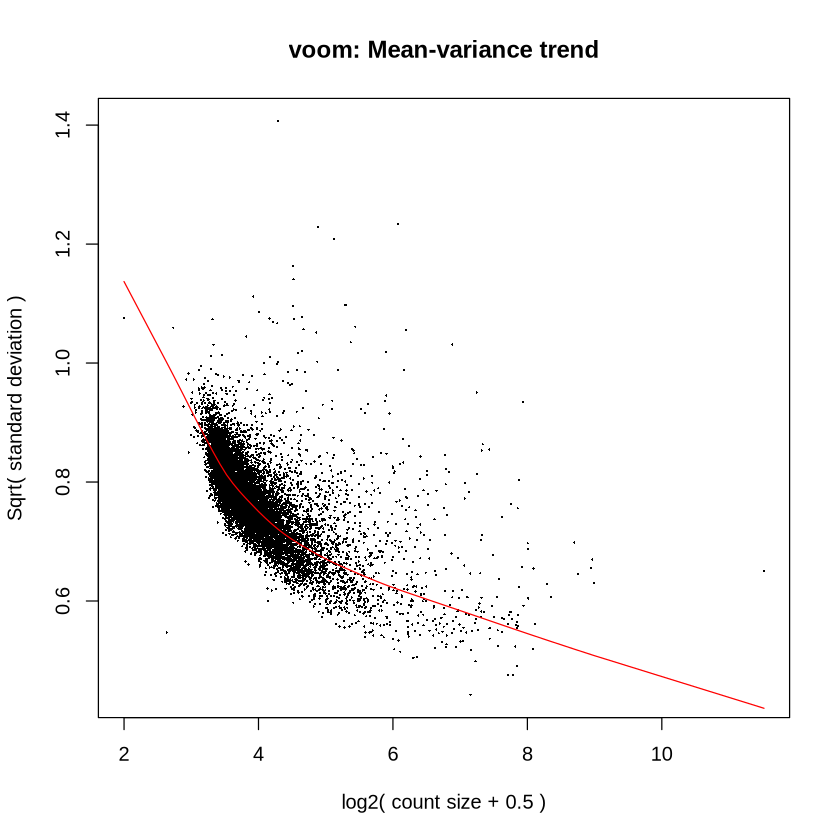

In [47]:
# Estimate correlation within slides
corfit <- duplicateCorrelation(voom(dge, design), block = block_var)

# Run voom with duplicate correlation
v <- voom(dge, design, block = block_var, correlation = corfit$consensus, plot = T)

# Fit the model
fit <- lmFit(v, design, block = block_var, correlation = corfit$consensus)
fit <- eBayes(fit)

We also check the value of the concensus correlation, part of the output of the `duplicateCorrelation` function.

If the value is < 0.1, blocking might not as needed. 
If the value is >0.5, you might need a second round of duplicateCorrelation, same code, but using the residuals of the first model. 

In this case, `corfit$consensus.correlation` is **`r round(corfit$consensus.correlation, digits = 3)`**, so the batch seems to have an observable effect.

In [48]:
# Extract results for a specific class effect within a cell type.
colnames( fit$coefficients )

[1] "glomeruli"           "ProximalTubules"     "DistalTubules"      
[4] "glomeruli_DKD"       "ProximalTubules_DKD" "DistalTubules_DKD"

#### Results

In this case we will focus on DE between disease and normal samples in glomeruli, which is represented by the `glomeruli_DKD` coefficient.

**Top 20 DEGs**

In [49]:
this_coef = 'glomeruli_DKD'
i = 'glomeruli'

## Extract all the results per gene: No filter for p-value nor logFC, with regular adjustment.
de <- topTable(fit, coef=this_coef,  number=Inf) %>% mutate(CellType = i) %>% rownames_to_column('Gene')
  
## Show DE. 
filter(de, adj.P.Val < 0.05 & abs(logFC) >= log2(1.5)) %>% 
    dplyr::select(Gene, logFC, P.Value, adj.P.Val) %>% 
    arrange(desc(abs(logFC))) %>% head(n = 20) 
    #knitr::kable(caption = paste0('Top 20 DEGs\nDKD vs Normal, ', i))

,Gene,logFC,P.Value,adj.P.Val
,<chr>,<dbl>,<dbl>,<dbl>
1,TSPY1,1.707835,1.562021e-07,3.729512e-05
2,SUPT7L,-1.528025,1.711139e-10,1.319946e-07
3,IL1RL1,-1.484195,9.039370e-06,9.137004e-04
4,NELL1,1.473469,1.319596e-06,2.035832e-04
5,DEFA1B,1.450012,6.777220e-04,2.302816e-02
6,CDKN1C,-1.416080,1.544570e-13,1.548894e-09
7,SLC2A3,1.376519,1.923474e-07,4.103957e-05
8,NDNF,-1.332004,1.583222e-11,1.984569e-08
9,RBMY1J,1.322612,2.709050e-07,5.224299e-05


###  Vocano Plot

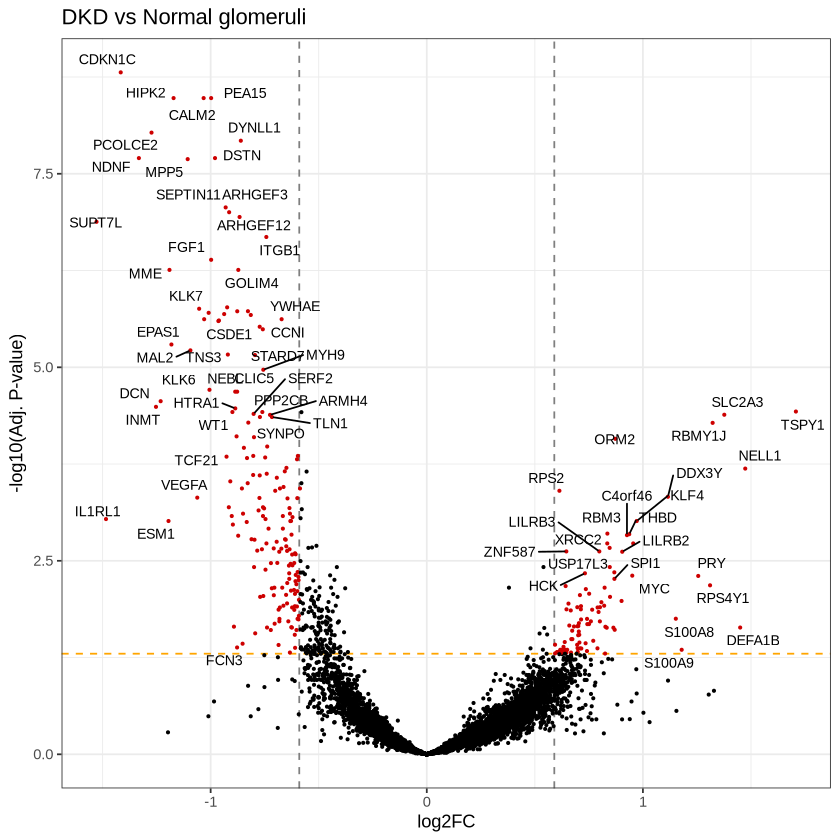

In [50]:
## Volcano plot
de %>% mutate(sig = adj.P.Val < 0.05 & abs(logFC) >= log2(1.5), gene = ifelse(sig == T, Gene, '')) %>% 
    ggplot(aes(x = logFC, y = -log10(adj.P.Val), color = sig, label = gene)) + theme_bw() +
    geom_hline(yintercept = 1.3, color = 'orange', linetype = 'dashed') + 
    geom_vline(xintercept = c(-0.59, 0.59),  color = 'grey50', linetype = 'dashed') +
    geom_point(size = 0.5) + geom_text_repel(size = 3, color = 'black', max.overlaps = 15) + 
    scale_color_manual(values = c(`FALSE` = 'black', `TRUE` = 'red3')) +
    theme(legend.position = 'none') + labs(title = paste('DKD vs Normal', i), y = '-log10(Adj. P-value)', x = 'log2FC')

In [51]:
## Store DE results in the results folder. 
write_tsv(de, file.path(out_dir, paste0('DE_', i, '_DKDvsNormal.tsv')))

#### Heatmaps

For visualization, we can use one of the batch corrected datasets, in this case, we will use the limma batch corrected dataset.

We will plot the logNorm expression in the Top 20 DEG in Glomeruli.

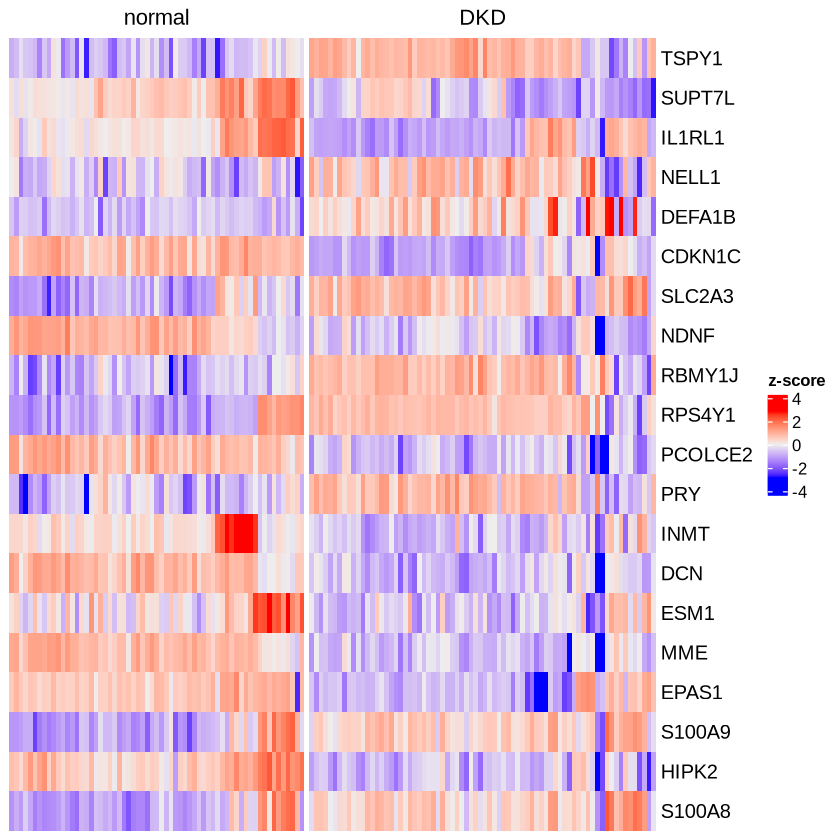

In [52]:
## Heatmaps: Top 20 DEGs. 
top_20 = filter(de, adj.P.Val < 0.05 & abs(logFC) >= log2(1.5)) %>% 
    dplyr::select(Gene, logFC, P.Value, adj.P.Val) %>% 
    arrange(desc(abs(logFC))) %>% head(n = 20) %>% pull('Gene')

norm_mx = logcpm[top_20, metadata$CellType == i]
scale(norm_mx) -> norm_mx


ComplexHeatmap::Heatmap(logcpm[top_20, metadata$CellType == i], 
                        name = 'logCPM', col = c('white', 'red3'),
                        column_split = metadata$class[metadata$CellType == i],
                        cluster_rows = F, cluster_columns = F, show_row_names = T, show_column_names = F)

norm_mx = logcpm[top_20, metadata$CellType == i] %>% t %>% scale()

ComplexHeatmap::Heatmap(t(norm_mx), 
                        name = 'z-score', 
                        column_split = metadata$class[metadata$CellType == i],
                        cluster_rows = F, cluster_columns = F, show_row_names = T, show_column_names = F)

## R Session

In [53]:
map(sessionInfo()$otherPkgs, ~.x$Version)

$PCAtools
[1] "2.14.0"

$ggrepel
[1] "0.9.8"

$ggalluvial
[1] "0.12.6"

$edgeR
[1] "4.0.16"

$limma
[1] "3.58.1"

$lubridate
[1] "1.9.4"

$forcats
[1] "1.0.0"

$stringr
[1] "1.5.2"

$dplyr
[1] "1.1.4"

$purrr
[1] "1.1.0"

$readr
[1] "2.1.5"

$tidyr
[1] "1.3.1"

$tibble
[1] "3.3.0"

$ggplot2
[1] "4.0.2"

$tidyverse
[1] "2.0.0"